## About Dataset
Context
This is a subset of dataset of Book reviews from Amazon Kindle Store category.

Columns:
- rating - rating of the product (1 to 5)
- reviewText - text of the review
- summary - summary of the review

#### Best Practises
1. Preprocessing And Cleaning
2. Train Test Split (Preventing Data Leakage)
3. BOW & TFIDF Models
4. Word2Vec & Average Word2Vec Model
5. Model Training & Comparative Evaluation

In [1]:
# Load the dataset
import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file_path = 'Kindle Reviews/all_kindle_review.csv' if os.path.exists('Kindle Reviews/all_kindle_review.csv') else 'all_kindle_review.csv'
url = 'https://raw.githubusercontent.com/Abhigyan-RA/NLP-basics/main/all_kindle_review.csv'

if not os.path.exists(file_path):
    print('Downloading all_kindle_review.csv...')
    urllib.request.urlretrieve(url, file_path)

data = pd.read_csv(file_path)
data.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [3]:
df = data[['reviewText', 'rating']]
df.head()

,reviewText,rating
0,"Jace Rankin may be short, but he's nothing to ...",3
1,Great short read. I didn't want to put it dow...,5
2,I'll start by saying this is the first of four...,3
3,Aggie is Angela Lansbury who carries pocketboo...,3
4,I did not expect this type of book to be in li...,4


In [4]:
df.shape

(12000, 2)

In [5]:
## Missing Values
df.isnull().sum()

reviewText    0
rating        0
dtype: int64

In [6]:
df['rating'].unique()

array([3, 5, 4, 2, 1])

In [7]:
df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

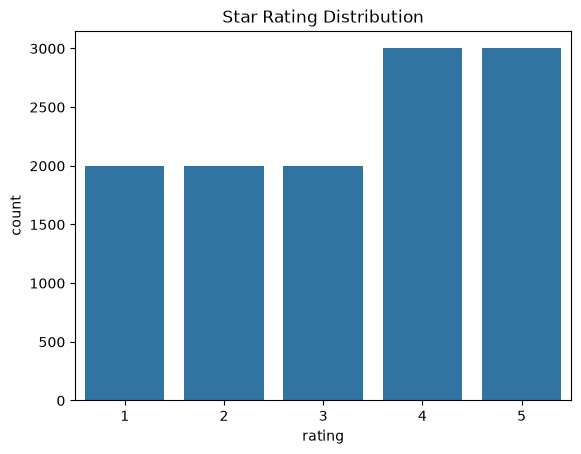

In [8]:
## EDA: Visualizing Star Rating Distribution
sns.countplot(x='rating', data=df)
plt.title('Star Rating Distribution')
plt.show()

## Preprocessing And Cleaning

In [9]:
## positive review is 1 and negative review is 0
df['rating'] = df['rating'].apply(lambda x: 0 if x < 3 else 1)

In [10]:
df['rating'].value_counts()

rating
1    8000
0    4000
Name: count, dtype: int64

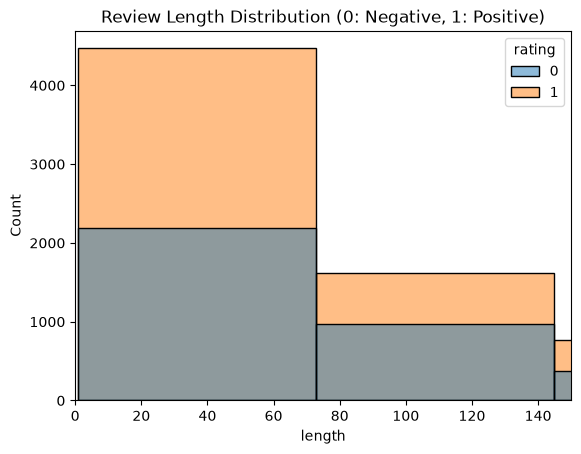

In [11]:
## EDA: Review Length Distribution by Sentiment
df['length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
sns.histplot(x='length', hue='rating', data=df, bins=30)
plt.xlim(0, 150)
plt.title('Review Length Distribution (0: Negative, 1: Positive)')
plt.show()

In [12]:
## 1. Lower All the cases
df['reviewText'] = df['reviewText'].astype(str).str.lower()

In [13]:
df.head()

,reviewText,rating,length
0,"jace rankin may be short, but he's nothing to ...",1,541
1,great short read. i didn't want to put it dow...,1,69
2,i'll start by saying this is the first of four...,1,76
3,aggie is angela lansbury who carries pocketboo...,1,54
4,i did not expect this type of book to be in li...,1,20


In [14]:
import re
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [15]:
from bs4 import BeautifulSoup

In [16]:
## Removing special characters
df['reviewText'] = df['reviewText'].apply(lambda x: re.sub('[^a-z A-z 0-9-]+', '', str(x)))

In [17]:
df.head()

,reviewText,rating,length
0,jace rankin may be short but hes nothing to me...,1,541
1,great short read i didnt want to put it down ...,1,69
2,ill start by saying this is the first of four ...,1,76
3,aggie is angela lansbury who carries pocketboo...,1,54
4,i did not expect this type of book to be in li...,1,20


In [18]:
## Lemmatizer
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

In [19]:
def lemmatize_words(text):
    return ' '.join([lemmatizer.lemmatize(word) for word in text.split()])

In [20]:
df['reviewText'] = df['reviewText'].apply(lambda x: lemmatize_words(x))

In [21]:
df.head()

,reviewText,rating,length
0,jace rankin may be short but he nothing to mes...,1,541
1,great short read i didnt want to put it down s...,1,69
2,ill start by saying this is the first of four ...,1,76
3,aggie is angela lansbury who carry pocketbook ...,1,54
4,i did not expect this type of book to be in li...,1,20


## Train Test Split

In [22]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df['reviewText'], df['rating'], test_size=0.20, random_state=42)

In [23]:
len(X_train), len(X_test)

(9600, 2400)

## 1. Bag of Words Model

In [24]:
from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer(max_features=5000)
X_train_bow = bow.fit_transform(X_train).toarray()
X_test_bow = bow.transform(X_test).toarray()

In [25]:
from sklearn.naive_bayes import MultinomialNB
nb_model_bow = MultinomialNB().fit(X_train_bow, y_train)

In [26]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
y_pred_bow = nb_model_bow.predict(X_test_bow)

In [27]:
print('BOW accuracy: ', accuracy_score(y_test, y_pred_bow))
confusion_matrix(y_test, y_pred_bow)

BOW accuracy:  0.8329166666666666


array([[ 677,  126],
       [ 275, 1322]])

In [28]:
print(classification_report(y_test, y_pred_bow))

              precision    recall  f1-score   support

           0       0.71      0.84      0.77       803
           1       0.91      0.83      0.87      1597

    accuracy                           0.83      2400
   macro avg       0.81      0.84      0.82      2400
weighted avg       0.85      0.83      0.84      2400



## 2. TF-IDF Model

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train).toarray()
X_test_tfidf = tfidf.transform(X_test).toarray()

In [30]:
nb_model_tfidf = MultinomialNB().fit(X_train_tfidf, y_train)

In [31]:
y_pred_tfidf = nb_model_tfidf.predict(X_test_tfidf)

In [32]:
print('TFIDF accuracy: ', accuracy_score(y_test, y_pred_tfidf))
confusion_matrix(y_test, y_pred_tfidf)

TFIDF accuracy:  0.8016666666666666


array([[ 369,  434],
       [  42, 1555]])

In [33]:
print(classification_report(y_test, y_pred_tfidf))

              precision    recall  f1-score   support

           0       0.90      0.46      0.61       803
           1       0.78      0.97      0.87      1597

    accuracy                           0.80      2400
   macro avg       0.84      0.72      0.74      2400
weighted avg       0.82      0.80      0.78      2400



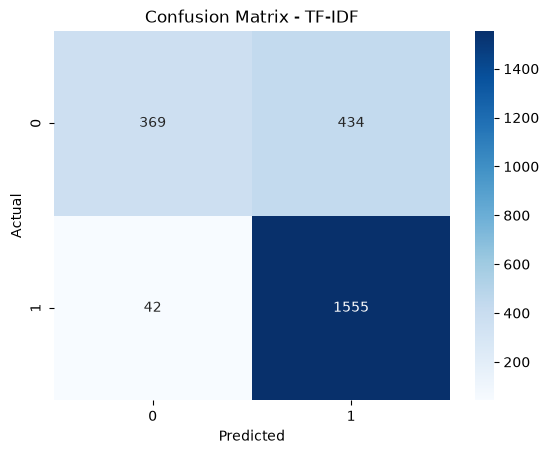

In [34]:
## Confusion Matrix Heatmap for TF-IDF
sns.heatmap(confusion_matrix(y_test, y_pred_tfidf), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - TF-IDF')
plt.show()

## 3. Word2Vec and Average Word2Vec Model

In [35]:
## Tokenizing cleaned reviews for Word2Vec training
corpus = [text.split() for text in df['reviewText']]
corpus[0][:10]

['jace', 'rankin', 'may', 'be', 'short', 'but', 'he', 'nothing', 'to', 'mess']

In [36]:
## Training Word2Vec model on Kindle reviews
import gensim
from gensim.models import Word2Vec
w2v_model = Word2Vec(corpus, vector_size=100, window=5, min_count=2, workers=4)

In [37]:
len(w2v_model.wv.key_to_index)

17914

In [38]:
## Exploring semantic similarity
w2v_model.wv.most_similar('good')

[('great', 0.8100855350494385),
 ('nice', 0.7445578575134277),
 ('decent', 0.7197444438934326),
 ('bad', 0.6432012915611267),
 ('quick', 0.6419472098350525),
 ('okay', 0.6317858695983887),
 ('fine', 0.6280965209007263),
 ('complete', 0.6205241680145264),
 ('short', 0.6130604147911072),
 ('interesting', 0.6073170304298401)]

In [39]:
w2v_model.wv.most_similar('boring')

[('confusing', 0.8652412295341492),
 ('predictable', 0.8577442765235901),
 ('rushed', 0.8210855722427368),
 ('slow', 0.816957950592041),
 ('annoying', 0.7935320734977722),
 ('distracting', 0.7885889410972595),
 ('repetitive', 0.7730305790901184),
 ('ok', 0.7526317238807678),
 ('disappointing', 0.7488034963607788),
 ('okay', 0.7475457787513733)]

In [40]:
## Function to compute Average Word2Vec for each document
def avg_word2vec(doc):
    words = [w for w in doc if w in w2v_model.wv]
    if len(words) == 0:
        return np.zeros(100)
    return np.mean([w2v_model.wv[w] for w in words], axis=0)

In [41]:
avg_word2vec(corpus[0]).shape

(100,)

In [42]:
## Computing Average Word2Vec for all reviews
X_w2v = np.array([avg_word2vec(doc) for doc in corpus])
X_w2v.shape

(12000, 100)

In [43]:
## Train Test Split for Word2Vec features using same split
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v, df['rating'].values, test_size=0.20, random_state=42
)
X_train_w2v.shape, X_test_w2v.shape

((9600, 100), (2400, 100))

In [44]:
## Training Logistic Regression on Word2Vec features
from sklearn.linear_model import LogisticRegression
lr_w2v = LogisticRegression(max_iter=1000)
lr_w2v.fit(X_train_w2v, y_train_w2v)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [45]:
y_pred_w2v = lr_w2v.predict(X_test_w2v)

In [46]:
print('Word2Vec Accuracy: ', accuracy_score(y_test_w2v, y_pred_w2v))
confusion_matrix(y_test_w2v, y_pred_w2v)

Word2Vec Accuracy:  0.7933333333333333


array([[ 480,  323],
       [ 173, 1424]])

In [47]:
print(classification_report(y_test_w2v, y_pred_w2v))

              precision    recall  f1-score   support

           0       0.74      0.60      0.66       803
           1       0.82      0.89      0.85      1597

    accuracy                           0.79      2400
   macro avg       0.78      0.74      0.76      2400
weighted avg       0.79      0.79      0.79      2400



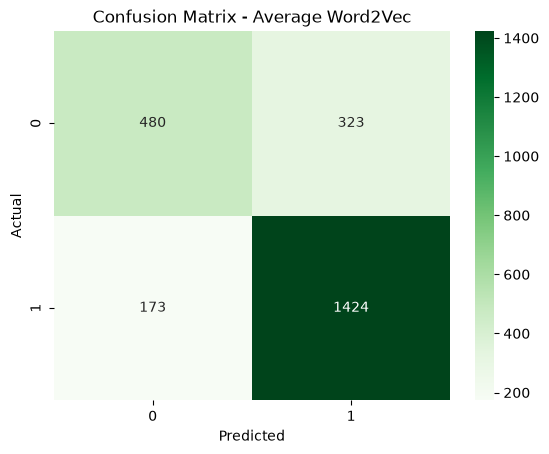

In [48]:
## Confusion Matrix Heatmap for Word2Vec
sns.heatmap(confusion_matrix(y_test_w2v, y_pred_w2v), annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Average Word2Vec')
plt.show()

## 4. Performance Comparison

In [49]:
## Comparative Performance Summary
comparison = pd.DataFrame({
    'Vectorization': ['Bag of Words', 'TF-IDF', 'Average Word2Vec'],
    'Classifier': ['MultinomialNB', 'MultinomialNB', 'LogisticRegression'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_bow),
        accuracy_score(y_test, y_pred_tfidf),
        accuracy_score(y_test_w2v, y_pred_w2v)
    ]
})
comparison

,Vectorization,Classifier,Accuracy
0,Bag of Words,MultinomialNB,0.832917
1,TF-IDF,MultinomialNB,0.801667
2,Average Word2Vec,LogisticRegression,0.793333


# Summary

More complex feature representations do not automatically mean higher sentiment accuracy. For sentimentbtasks with Naive Bayes, Bag of Words retains raw word frequency, whereas TF-IDF penalizes common sentiment adjectives through IDF downweighting, and Average Word2Vec dilutes polarity words across the review length.